# A Tutorial for Differentiable Simulation

This notebook accompanies the DiffEC project as a tutorial of Differentiable Simulation for and beyond electrochemistry. This tutorial is more a step-by-step guide to learn the art of Differentiable Simulation with JAX. The tutorial consists of four parts: 

1. Automatic Differentiation for Linear Regression with JAX
2. Differentiable simulation for electrochemical kinetics
3. Implementing a differentiable finite-difference simulator. Note that a conventional simulator implemented using JAX is also provided for "side-by-side" comparison.
4. Differentiable simulator and parameter estimation for Fe Redox Voltammetry


This notebook was tested Python 3.13.1, JAX 0.4.35 and optax 0.2.4, and should be readily runnable on a Google Colab. 

In this tutorial, we use JAX for the benefits of automatic differentiation, native with Python and Numpy, and Just-In-Time Compilation, allowing for speedups of Python functions into optimized machine code. 

It is note that PyTorch, Julia and other frameworks also support automatic differentiation (AD), such that the art of Differentiable Simulation should not be bound to 



The major highlights of JAX are:

1. JAX provides a familiar Numpy API, so converting from Numpy to JAX is relatively straightforward 
2. JAX primarily follows a **functional** programming paradigm, which encourages stateless, pure functions. On the contrary, Numpy simulators allows more freedom. The Numpy simulator below uses a more Pythonic, **object oriented** approach.
3. JAX offers three major advantages: 
    * Just-in-time (JIT) compilation: Perform JIT complication of a JAX function so that it can be executed more efficiently. 
    * Automatic Vectorization: jax.vmap() generate vectorized implementation of functions automatically. 
    * Automatic Differentiation: jax.grad() and jax.value_and_grad() are handy functions that evaluate the value and/or the gradient of a function. The entire simulation function is thus differentiable. 
4. JAX arrays are **immutable** for speedup requirement. To make updates to JAX arrays, one must use the .at accessor (arr.at[idx].set(val))
 

## 1. Learning the Basics: Automatic Differentiation for Linear Regression with JAX 

This tutorial aims to introduce Differentiable Simulation using Linear Regression (y=ax+b). This case serves the starting point to understand JAX lanaguage for computing and Optax for optimization.

In a classic linear regression problem, we are given a set of (x,y) and wants to estimate the slope (a) and the intercept (b).

In [24]:
#Import required packages
import jax
import jax.numpy as jnp
import numpy as np
from matplotlib import pyplot as plt
import optax 
jax.config.update("jax_enable_x64", True) #It's very important to enable float64 in JAX computation; The default float 32 does not satisfy the precision requirement. This is especially important for the Li kinetics model.

Text(0, 0.5, 'y')

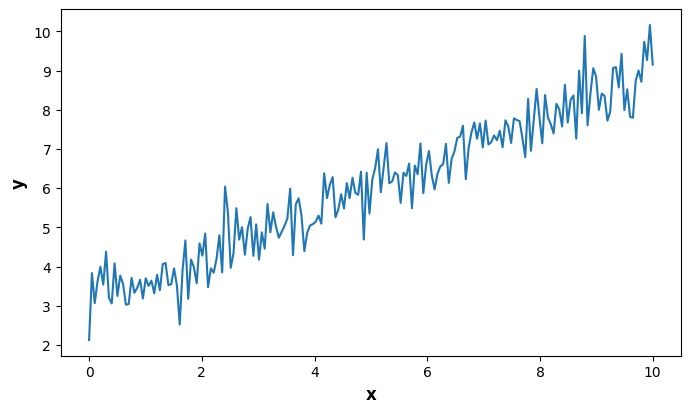

In [25]:
# Problem setup and visalize the linear regression problem 

key = jax.random.key(seed=42) # Initialize the randomized state 

x = jnp.linspace(0,10,num=200)

y = x*0.6 + 3 + jax.random.normal(key,x.shape)*0.5 #Generate y with noise 


fig,ax = plt.subplots(figsize=(8,4.5))
ax.plot(x,y)
ax.set_xlabel("x",fontsize="large",fontweight='bold')
ax.set_ylabel("y",fontsize="large",fontweight="bold")


In [26]:
#Now make an initial guess for the two parameters 
a_i = 1.2 
b_i = 4.0

#Next we define the moss function, can be mean squared error (MSE) or mean absolute error (MAE), or other scores. 
#Define the mean suqare error loss function
def mse(y_true,y_pred):
    loss = jnp.mean((y_true - y_pred) ** 2)
    return loss

#Next we make predictions using our gusses parameters
y_pred = a_i *x + b_i

#Then we can calculate the loss of the predicted and true y values. 
loss = mse(y_true=y,y_pred=y_pred)

#We can print loss
loss



Array(19.20741284, dtype=float64)

Importantly, Jax allows us to directly calculate the gradient of the loss with respect to parameters using jax.grad(fun) or jax.value_and_grad(fun). In principle, JAX creates a function that can evaluate the gradient of the input function (fun).
 
Let's see an example. 


In [27]:


def compute_loss(params):
    a_i = params[0]
    b_i = params[1]

    y_pred = a_i * x + b_i

    loss = mse(y,y_pred)

    return loss 

value_and_grad = jax.value_and_grad(compute_loss)

params = [a_i,b_i]
loss,loss_grad = value_and_grad(params)


In [28]:
# Here we can inspect the loss 
print(f"The loss is {loss}")

The loss is 19.20741284231555


In [29]:
# We can also inspect the gradients 
print(f"The gradients of loss with respect to a is {loss_grad[0]}")
print(f"The gradients of loss with respect to b is {loss_grad[1]}")

The gradients of loss with respect to a is 50.01186572728696
The gradients of loss with respect to b is 7.969199930051532


In [30]:
# Here we can perform manual gradient based optimization 
lr = 1e-2 # The learning rate 
a_i = a_i - lr * loss_grad[0]
b_i = b_i - lr * loss_grad[1]

print(f"The new parameters after one step of optimization is:\na_i={a_i}\nb_i={b_i}")


The new parameters after one step of optimization is:
a_i=0.6998813427271303
b_i=3.920308000699485


After one epoch of optimization as we observe above, we can put the optimization process in an optimization loop.

In [31]:
#Reinitialize parameters 
a_i = 1.2  
b_i = 4.0
params = [a_i,b_i]

epochs = 4000
lr = 1e-2

#Here we start the differentiable simulation optimization loop
loss_history = []
a_history = []
b_history = []

for i in range(epochs):
    loss,loss_grad = value_and_grad(params)

    params[0] = params[0] - lr*loss_grad[0] # gradient based update of parameter a 
    params[1] = params[1] - lr*loss_grad[1] # gradient based update of parameter b

    loss_history.append(loss)

    a_history.append(params[0])
    b_history.append(params[1])


Text(0.5, 0, 'Epochs')

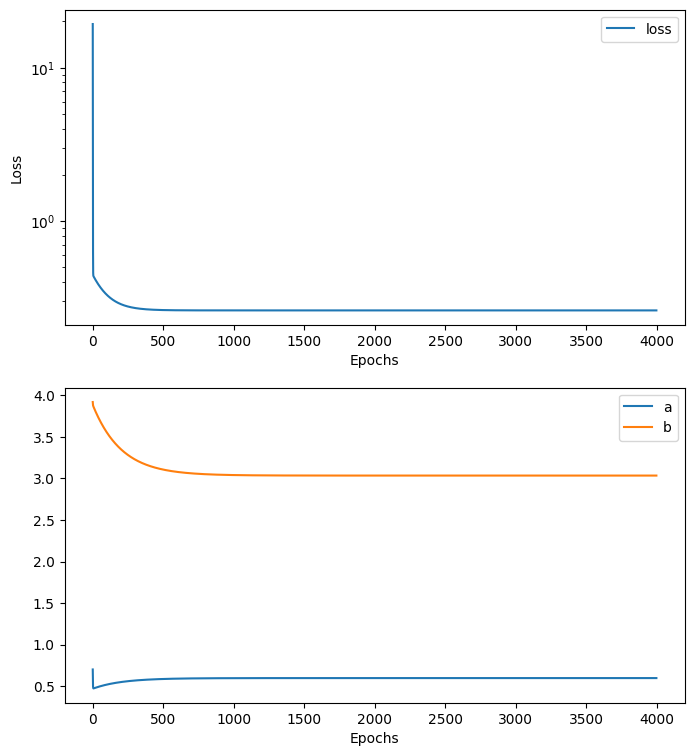

In [32]:
# Let's then visualize our training results 

fig, axs = plt.subplots(figsize=(8,9),nrows=2)

ax = axs[0]

ax.plot(loss_history,label="loss")
ax.set_yscale("log")
ax.legend()
ax.set_xlabel("Epochs")
ax.set_ylabel("Loss")

ax = axs[1]
ax.plot(a_history,label="a")
ax.plot(b_history,label="b")
ax.legend()
ax.set_xlabel("Epochs")


Besides manually updating parameters, we can also use optax's optimization library, including, Adam optimizer 

In [33]:
#Initialize Adam optimizer
optimizer = optax.adam(lr)


#Reinitialize parameters 
a_i = 1.2  
b_i = 4.0
params = [a_i,b_i]

epochs = 4000
lr = 5e-2

#Here we start the differentiable simulation optimization loop
loss_history = []
a_history = []
b_history = []

#Initialize optimizer state 
opt_state = optimizer.init(params)

for i in range(epochs):
    loss,loss_grad = value_and_grad(params)

    updates,opt_state = optimizer.update(loss_grad, opt_state,params)

    params = optax.apply_updates(params,updates)

    loss_history.append(loss)

    a_history.append(params[0])
    b_history.append(params[1])


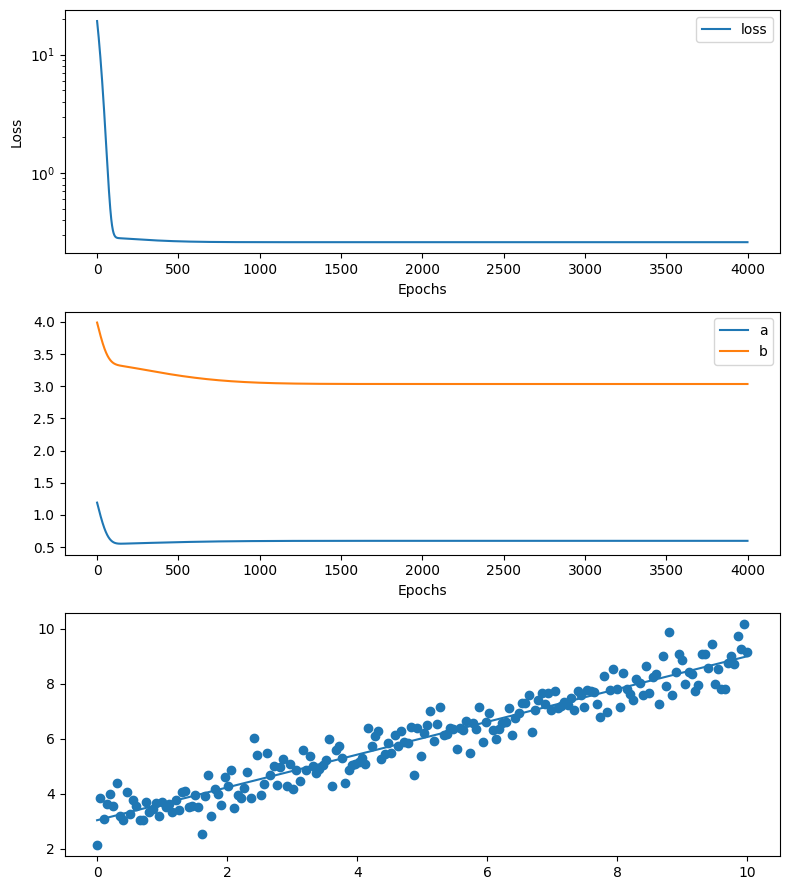

In [34]:
# Let's then visualize our training results 

fig, axs = plt.subplots(figsize=(8,9),nrows=3)

ax = axs[0]

ax.plot(loss_history,label="loss")
ax.set_yscale("log")
ax.legend()
ax.set_xlabel("Epochs")
ax.set_ylabel("Loss")

ax = axs[1]
ax.plot(a_history,label="a")
ax.plot(b_history,label="b")
ax.legend()
ax.set_xlabel("Epochs")

ax = axs[2]
ax.scatter(x,y)
ax.plot(x, x*a_history[-1]+b_history[-1],label='Fitted Line')
plt.tight_layout()

In [35]:
# Lastly, we print the optimization results! 
print("The optimized slope is",a_history[-1])
print("The optimized intercept is", b_history[-1])

#The optimize parameters are very close to the ground truth, considering the intrinsic random noise, the flat loss and optimized parameters trajectories, this looks like a good fit. 

The optimized slope is 0.5961172091555718
The optimized intercept is 3.034813989196377


## 2. Differentiable simulation for electrochemical kinetics 

In this tutorial, we reproduce part of Differentiable Electrochemistry fitting of the Li overpotential/current data reported by Boyle et al using Marcus-Hush-Chidsey (MHC) model. In this tutorial, we will perform the following steps:

1. Construct a fully differentiable Marcus-Hush-Chidsey kinetic model using Gauss-Hermite polynomial
2. Construct a fully differentiable loss function that compares MHC kinetic prediction with experimental current density. The loss is fully differentiable with respect to MHC model parameters including exchange current density and reorganization energy.
3. Differentiable Electrochemistry optimization (Taking 2-3 mins for 4000 epochs)

In [36]:


#Step 1, Define a fully differentiable MHC kinetics
def MHC_current(j0,reorg_e,eta):
    """
    MHC kinetics implemented with Gauss-Hermite. 
    args:
        j0: exchange current density, mA/cm^2
        eta: Overpotential. Volt
        reorg_e: Reorganization energy in eV. 
    returns:
        Absolute current density at overpotential eta, with a unit of mA/cm^2. 
    """
    F = 96485 # Faraday Constant 
    R = 8.314 # Gas Constant 
    T = 298 # k 
    theta = eta*(F/(R*T)) #Dimensionless potential 
    Lambda = reorg_e * (F/(R*T)) # Dimensionless reorganization energy 

    def MHIntegrand_Red(theta,Lambda=Lambda,hermgauss_degree=50):
        sample_points,weights = np.polynomial.hermite.hermgauss(hermgauss_degree)
        def integrand(u):
            #The Gauss-Hermite integrand for reduction reaction. 
            return 2*jnp.sqrt(Lambda)/(1.0+jnp.exp(-(Lambda*(u*2.0/jnp.sqrt(Lambda)-1.0)-theta)))
        y = integrand(sample_points)
        return jnp.sum(weights*y)
    
    def MHIntegrand_Ox(theta,Lambda=Lambda,hermgauss_degree=50):
        sample_points,weights = np.polynomial.hermite.hermgauss(hermgauss_degree)
        def integrand(u):
            #The Gauss-Hermite integrand for oxidation reaction.
            return -2.0*jnp.sqrt(Lambda)/(1.0+jnp.exp(-Lambda*(u*2.0/jnp.sqrt(Lambda)-1.0)-theta))
        y = integrand(sample_points)
        return jnp.sum(weights*y)
    

    kred = jax.vmap(MHIntegrand_Red)(theta)/MHIntegrand_Red(0.0)
    kox =  jax.vmap(MHIntegrand_Ox)(theta)/MHIntegrand_Ox(0.0)

    j_MHC = j0*(kred-kox)

    return jnp.abs(j_MHC)

def mse(y_true,y_pred):
    loss = jnp.mean((y_true - y_pred) ** 2)
    return loss

def compute_loss_MHC(params,expt_eta,expt_current_density):

    #The loss function comparing the MSE loss between MHC model current and experimental current density. 
    # The resulting loss is differentiable with respect to its parameters.

    j0 = params[0]
    reorg_e = params[1]
    
    j_MHC = MHC_current(j0=j0,reorg_e=reorg_e,eta=expt_eta)

    loss = mse(expt_current_density,j_MHC)

    return loss 

#Use jax.value_and_grad function to create a differentiable loss function.
value_and_grad_MHC = jax.value_and_grad(compute_loss_MHC,argnums=0) 


100%|██████████| 4000/4000 [01:37<00:00, 41.21it/s]


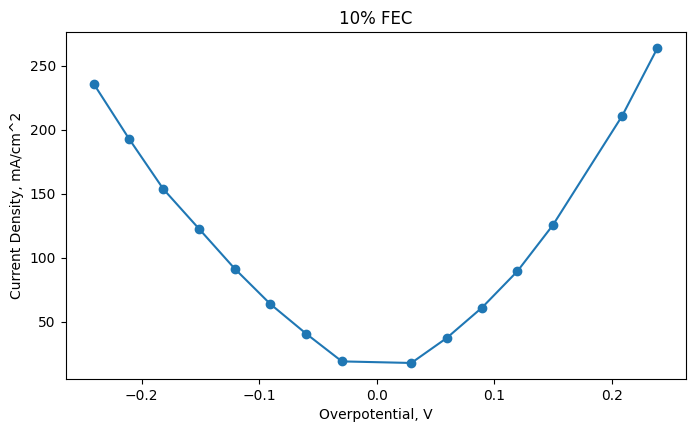

In [37]:
import pandas as pd
import tqdm
j0_initial_guess_central = 5 # mA/cm^2 
reorg_e_initial_guess_central = 0.25 #eV


j0_initial_guess_range = 0.5
reorg_e_initial_guess_range  = 0.05 #eV
optimizer_name = "adam"
lr = 2e-2
epochs = 4000


system_names = [r"10% FEC",r'EC DEC',r'DEC',r'PC'][:1]  # Let's analyze the 10% FEC data only to save time. 
df = pd.read_csv("./DiffEC for Mechanistic Identification Li Metal Anode/Boyle Figure 4a.csv",skiprows=1)

for index, system_name in enumerate(system_names):
    expt_eta = jnp.array(df.iloc[:,index*2].dropna())
    expt_current_density = jnp.array(df.iloc[:,index*2+1].dropna())

    #Let's visualize the experimental datapoints 
    fig,ax = plt.subplots(figsize=(8,4.5))
    ax.plot(expt_eta,expt_current_density,marker='o')
    ax.set_title(f"{system_name}")
    ax.set_xlabel("Overpotential, V")
    ax.set_ylabel("Current Density, mA/cm^2")


    #Generate initial guess for exchange current density and reorganization energy 
    j0_initial_guess = np.random.uniform(j0_initial_guess_central-j0_initial_guess_range,j0_initial_guess_central+j0_initial_guess_range)
    reorg_e_initial_guess = np.random.uniform(reorg_e_initial_guess_central-reorg_e_initial_guess_range,reorg_e_initial_guess_central+reorg_e_initial_guess_range)


    #Select optimizers and initialize optimizers. 
    params = jnp.array([j0_initial_guess,reorg_e_initial_guess]) 
    if optimizer_name == "sgd":
        optimizer = optax.sgd(lr)
    elif optimizer_name =='adam':
        optimizer = optax.adam(lr)
    else:
        raise ValueError
    opt_state = optimizer.init(params)


    j0_history = []
    reorg_e_history = []
    rmse_loss_history = []




    # Here starts the optimization cycle. 
    for i in tqdm.tqdm(range(epochs)):
        #Caculate the loss of MHC kinetics and gradients of loss with respect to parameters 
        loss,grads = value_and_grad_MHC(params,expt_eta,expt_current_density)
        #Calculate updates for parameters with gradients generated from last step.
        updates,opt_state = optimizer.update(grads, opt_state,params)
        #Apply updates for parameters 
        params = optax.apply_updates(params,updates)
        #Cacluate RMSE error 
        rmse_loss = jnp.sqrt(loss)

        #Record history for optimization.
        j0_history.append(float(params[0]))
        reorg_e_history.append(float(params[1]))
        rmse_loss_history.append(float(rmse_loss))







The optimized exchange current density is 13.698147634593306 mA/cm^2
The optimized reorganization energy  is 0.20433326569447074 mA/cm^2
The RMSE loss is 7.9787504521508845 mA/cm^2


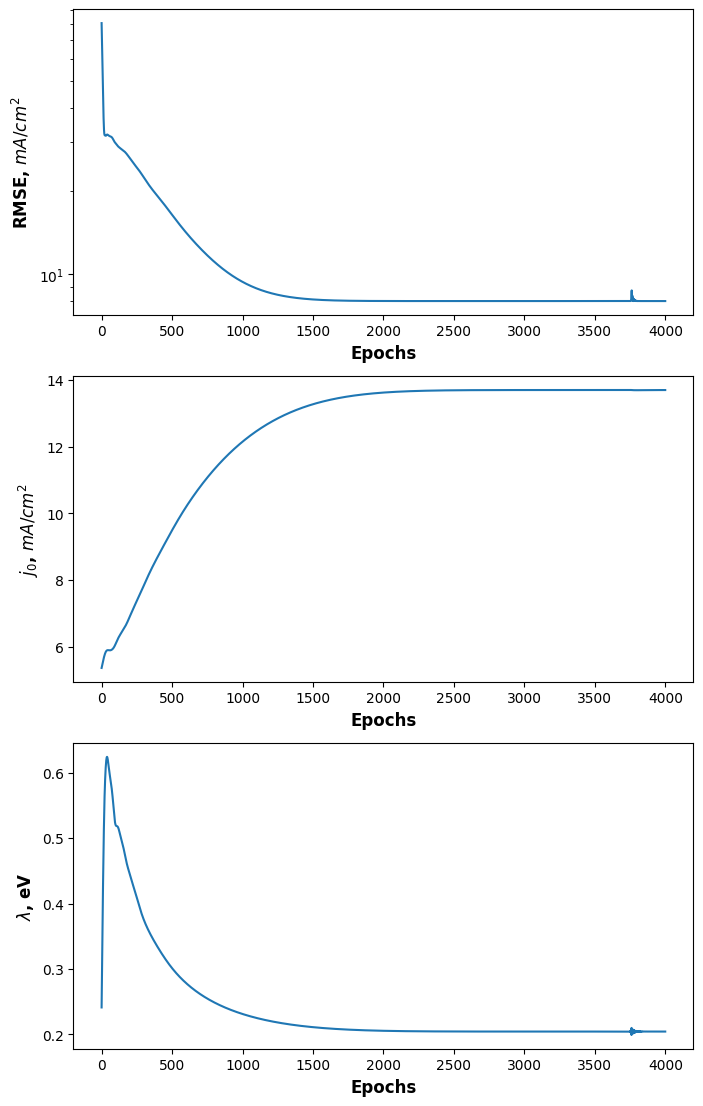

In [38]:
fig,axs = plt.subplots(figsize=(8,13.5),nrows=3)

ax = axs[0]
ax.plot(rmse_loss_history)
ax.set_yscale('log')
ax.set_xlabel('Epochs',fontsize='large',fontweight='bold')
ax.set_ylabel(r'RMSE, $mA/cm^2$',fontsize='large',fontweight='bold')

ax = axs[1]
ax.plot(j0_history)
ax.set_xlabel('Epochs',fontsize='large',fontweight='bold')
ax.set_ylabel(r'$j_0$, $mA/cm^2$',fontsize='large',fontweight='bold')

ax = axs[2]
ax.plot(reorg_e_history)
ax.set_xlabel('Epochs',fontsize='large',fontweight='bold')
ax.set_ylabel(r'$\lambda$, eV',fontsize='large',fontweight='bold')


print(f"The optimized exchange current density is {j0_history[-1]} mA/cm^2")
print(f"The optimized reorganization energy  is {reorg_e_history[-1]} mA/cm^2")
print(f"The RMSE loss is {rmse_loss_history[-1]} mA/cm^2")


## 3. Implementing a differentiable finite-difference simulator 

In this exercise, we will implement a voltammetry simulator using Numpy or JAx. Numpy is the conventional approach for simulation, and JAX is the more advanced, differentiable approach to simulation. By comparing the implementation of these two simulators, you learn the differences in a JAX implementation for automatic differentiation.  

* The JAX implementation is pure functional and stateless, which the Numpy implementation is more flexibile 
* Wrapping the simulator into the loss function, we use jax.value_and_grad() to obtain a new differentiable function that calcualtes the value of the loss and the gradient of the loss. 




## 3.1 A Conventional non-differentiable simulator implemented with Numpy 



In [39]:
import numpy as np 
import scipy
from scipy import sparse
from scipy.sparse import linalg
from matplotlib import pyplot as plt
import time
import pandas as pd 
import os


bulk_A = 1.0 # The bulk concentration of A and B, respectively.
bulk_B = 0.0



class Grid(object):
    """ 
    This class stores spatial grid and concentration profile during simualation.
    """
    def __init__(self,n,X_grid,K0,kinetics,alpha,beta,dA,dB):
        self.n = n
        self.X_grid =  X_grid
        self.K0 = K0
        self.kinetics = kinetics
        self.alpha = alpha
        self.beta = beta
        self.dA = dA
        self.dB = dB
        self.conc = np.zeros(2*self.n)
        self.conc_d = np.zeros(2*self.n)

    def init_c(self,A:float,B:float):
        self.conc[:self.n] = A
        self.conc[self.n:] = B
        self.conc_d = self.conc.copy()
    
    def grad(self):
        self.g = - self.dA*(self.conc[self.n-2]-self.conc[self.n-1])/(self.X_grid[1] - self.X_grid[0])

        return self.g

    def update_d(self,Theta,bulk_A,bulk_B):
        self.conc_d = self.conc.copy()


        if self.kinetics == 'Nernst':
            self.conc_d[self.n-1] = 1.0/(1.0+np.exp(-Theta))
            self.conc_d[self.n] = 0.0
        elif self.kinetics =='BV':
            X0 = self.X_grid[1]-self.X_grid[0]
            K_red = self.K0*np.exp(-self.alpha*Theta)
            K_ox = self.K0*np.exp(self.beta*Theta)
            self.conc_d[self.n-1] = 0.0
            self.conc_d[self.n] = 0.0
        else:
            raise ValueError
        self.conc_d[0] = bulk_A
        self.conc_d[2*self.n-1] = bulk_B

    def save_conc_profile(self,file_name):
        df  = pd.DataFrame({'X':self.X_grid,'Conc':self.conc})
        df.to_csv(file_name,index=False)


class Coeff(object):
    """
    This class stores coefficient for finite difference simulation. 
    """
    def __init__(self,n,deltaT,X_grid,K0,alpha,beta,kinetics,mode,dA,dB):
        self.n = n

        self.aA = np.zeros(self.n)
        self.bA = np.zeros(self.n)
        self.cA = np.zeros(self.n)
        self.aB = np.zeros(self.n)
        self.bB = np.zeros(self.n)
        self.cB = np.zeros(self.n)
        self.deltaT = deltaT

        self.X_grid = X_grid

        self.K0 = K0
        self.alpha = alpha
        self.beta = beta
        self.kinetics = kinetics
        self.mode = mode
        self.dA = dA # Dimensionless diffusion coefficient 
        self.dB = dB # Dimensionless diffusion coefficient 


        self.A_matrix = np.zeros((2*self.n,2*self.n))

    def update(self):
        pass


    def Acal_abc_radial(self,deltaT):
        
        self.aA[0] = 0.0
        self.bA[0] = 0.0
        self.cA[0] = 0.0

        for i in range(1,self.n-1):
            deltaX_m = self.X_grid[i] - self.X_grid[i - 1]
            deltaX_p = self.X_grid[i + 1] - self.X_grid[i]
            self.aA[i] = self.dA*((-(2.0 * deltaT) / (deltaX_m * (deltaX_m + deltaX_p)) + 2.0 / self.X_grid[i] * (deltaT / (deltaX_m + deltaX_p))))
            self.bA[i] = self.dA*(((2.0 * deltaT) / (deltaX_p * (deltaX_m + deltaX_p)) + (2.0 * deltaT) / (deltaX_m * (deltaX_m + deltaX_p)))) + 1.0
            self.cA[i] = self.dA*((-(2.0 * deltaT) / (deltaX_p * (deltaX_m + deltaX_p)) - 2.0 / self.X_grid[i] * (deltaT / (deltaX_m + deltaX_p))))

        self.aA[-1] = 0.0
        self.bA[-1] = 0.0
        self.cA[-1] = 0.0

    
    def Acal_abc_linear(self,deltaT):

        self.aA[0] = 0.0
        self.bA[0] = 0.0
        self.cA[0] = 0.0

        for i in range(1,self.n-1):
            deltaX_m = self.X_grid[i] - self.X_grid[i - 1]
            deltaX_p = self.X_grid[i + 1] - self.X_grid[i]
            self.aA[i] = self.dA*((-2.0*deltaT)/(deltaX_m*(deltaX_m+deltaX_p)))
            self.cA[i] = self.dA*((-2.0*deltaT)/(deltaX_p*(deltaX_m+deltaX_p)))
            self.bA[i] = 1.0-self.aA[i] - self.cA[i]
        self.aA[-1] = 0.0
        self.bA[-1] = 0.0
        self.cA[-1] = 0.0


    def Bcal_abc_radial(self,deltaT):
        self.aB[0] = 0.0
        self.bB[0] = 0.0
        self.cB[0] = 0.0

        for i in range(1,self.n-1):
            deltaX_m = self.X_grid[i] - self.X_grid[i - 1]
            deltaX_p = self.X_grid[i + 1] - self.X_grid[i]
            self.aB[i] = self.dB*((-(2.0 * deltaT) / (deltaX_m * (deltaX_m + deltaX_p)) + 2.0 / self.X_grid[i] * (deltaT / (deltaX_m + deltaX_p))))
            self.bB[i] = self.dB*(((2.0 * deltaT) / (deltaX_p * (deltaX_m + deltaX_p)) + (2.0 * deltaT) / (deltaX_m * (deltaX_m + deltaX_p)))) + 1.0
            self.cB[i] = self.dB*((-(2.0 * deltaT) / (deltaX_p * (deltaX_m + deltaX_p)) - 2.0 / self.X_grid[i] * (deltaT / (deltaX_m + deltaX_p))))

        self.aB[-1] = 0.0
        self.bB[-1] = 0.0
        self.cB[-1] = 0.0

    def Bcal_abc_linear(self,deltaT):

        self.aB[0] = 0.0  
        self.bB[0] = 0.0
        self.cB[0] = 0.0

        for i in range(1,self.n-1):
            deltaX_m = self.X_grid[i] - self.X_grid[i - 1]
            deltaX_p = self.X_grid[i + 1] - self.X_grid[i]
            self.aB[i] = self.dB*((-2.0*deltaT)/(deltaX_m*(deltaX_m+deltaX_p)))
            self.cB[i] = self.dB*((-2.0*deltaT)/(deltaX_p*(deltaX_m+deltaX_p)))
            self.bB[i] = 1.0-self.aB[i] - self.cB[i]
        self.aB[-1] = 0.0
        self.bB[-1] = 0.0
        self.cB[-1] = 0.0


    def Allcalc_abc(self,deltaT):
        if self.mode =='radial':
            self.Acal_abc_radial(deltaT)
            self.Bcal_abc_radial(deltaT)
        elif self.mode =='linear':
            self.Acal_abc_linear(deltaT)
            self.Bcal_abc_linear(deltaT)
        else:
            raise ValueError


    def CalcMatrix(self,Theta):

        if self.kinetics == 'Nernst':
            self.A_matrix[self.n-1,self.n-2] = 0.0
            self.A_matrix[self.n-1,self.n-1] = 1.0
            self.A_matrix[self.n-1,self.n] = 0.0
            
            self.A_matrix[self.n,self.n-2] = -self.dA
            self.A_matrix[self.n,self.n-1] = self.dA
            self.A_matrix[self.n,self.n] = self.dB
            self.A_matrix[self.n,self.n+1] = -self.dB

        elif self.kinetics =='BV':
            X0 = self.X_grid[1]-self.X_grid[0]
            K_red = self.K0*np.exp(-self.alpha*Theta)
            K_ox = self.K0*np.exp(self.beta*Theta)

            self.A_matrix[self.n-1,self.n-2] = -1.0
            self.A_matrix[self.n-1,self.n-1] = 1.0 + X0/self.dA*K_red
            self.A_matrix[self.n-1,self.n] = -X0/self.dA * K_ox

            self.A_matrix[self.n,self.n-1] = - X0/self.dB*K_red
            self.A_matrix[self.n,self.n] = (1.0 + X0/self.dB*K_ox)
            self.A_matrix[self.n,self.n+1] = -1.0
        else:
            raise ValueError
        
        for i in range(self.n-2,0,-1):

            self.A_matrix[i,i-1] = self.cA[(self.n-1)-i]
            self.A_matrix[i,i] = self.bA[(self.n-1)-i]
            self.A_matrix[i,i+1] = self.aA[(self.n-1)-i]


        for i in range(self.n+1,2*self.n-1):
            self.A_matrix[i,i-1] = self.aB[i-self.n]
            self.A_matrix[i,i] = self.bB[i-self.n]
            self.A_matrix[i,i+1] = self.cB[i-self.n]

        self.A_matrix[0,0] = 1.0
        self.A_matrix[0,1] = 0.0
        self.A_matrix[2*self.n-1,2*self.n-1] = 1.0
        self.A_matrix[2*self.n-1,2*self.n-2] = 0.0



        
def numpy_simulation(sigma=1.0,K0=1.0,alpha=0.5,beta=None,kinetics='BV',mode='linear',dA=1.0,dB=1.0,theta_i=20.0,theta_v = -20.0,saving_directory='./FD_Data',save_voltammogram=False):
    """
    args:
        sigma: Dimensionless scan rate
        K0: Standard electrochemical rate constants
        alpha: Transfer coefficient
        kinetics: Electrode kinetics, Nernst or BV
        mode: Mode of mass transport, linear or convergent
        dA and dB: dimensionless diffusion coefficient 
        theta_i: starting and ending potential of voltammetric scan
        theta_v: reverse potential of voltammetric scan 
        saving_directory of voltammetric scan.
    returns:
        E, fluxes: which are dimensionless fluxes and potentials
    """


    if not os.path.exists(saving_directory):
         os.mkdir(saving_directory)

    if beta is None:
        beta = 1.0-alpha

    #start and end potential of voltammetric scan
    cycles = 1
    deltaX = 5e-7 # The initial space step
    omega = 1.1 # Expanding grid factor
    deltaTheta = 1e-1
    deltaT = deltaTheta/sigma
    maxT = cycles*2.0*abs(theta_v-theta_i)/sigma
    if mode == 'linear':
        maxX = 6.0 * np.sqrt(maxT)
        X_grid = [0.0]
        x = 0.0
    elif mode == 'radial':
        maxX = 1.0 +  6.0 * np.sqrt(maxT)
        X_grid = [1.0]
        x = 1.0
    else:
        raise ValueError

    while x <= maxX:
        x += deltaX
        X_grid.append(x)
        deltaX *= omega
    n = len(X_grid)
    X_grid = np.array(X_grid)


    grid = Grid(n,X_grid,K0,kinetics,alpha,beta,dA,dB)
    grid.init_c(bulk_A,bulk_B)
    coeff = Coeff(n,deltaT,grid.X_grid,K0,alpha,beta,kinetics,mode,dA,dB)
    coeff.Allcalc_abc(deltaT=deltaT)

    #simulation steps
    nTimeSteps = int(2*np.fabs(theta_v-theta_i)/deltaTheta)+1
    Esteps = np.arange(nTimeSteps)
    E = np.where(Esteps<nTimeSteps/2.0,theta_i-deltaTheta*Esteps,theta_v+deltaTheta*(Esteps-nTimeSteps/2.0))
    E = np.tile(E,cycles)
    start_time = time.time()

    CV_location = f'{saving_directory}/sigma={sigma:.2E} K0={K0:.2E} alpha={alpha:.2E} beta={beta:.2E} kinetics={kinetics} mode={mode},dA={dA:.2E},dB={dB:.2E} theta_i={theta_i:.2E} theta_v={theta_v:.2E}'

    if os.path.exists(f'{CV_location}.csv'):
        print('File Exists')
        #return f'{CV_location}.csv'

    fluxes = []
    for index in range(0,int(len(E))):
        Theta = E[index]

        coeff.CalcMatrix(Theta)
        grid.update_d(Theta,bulk_A,bulk_B)

        grid.conc = linalg.spsolve(sparse.csr_matrix(coeff.A_matrix),sparse.csr_matrix(grid.conc_d[:,np.newaxis]))
        flux = grid.grad()
        fluxes.append(flux)
    if save_voltammogram:
        df = pd.DataFrame({'Potential':E,'Flux':fluxes})
        df.to_csv(f'{CV_location}.csv',index=False)
    return E,fluxes




## 3.2 A differentiable simulator implemented with JAX

The JAX implementation of a Finite Difference simulator. It is important to note that:
1. The implementation are purely functional and stateless. 
2. Modifying coefficient matrix are carried out as less frequently as possible to save computational time. 



In [ ]:
import numpy as np
import jax.numpy as jnp
import jax.scipy.linalg as liang
import os 
import jax


jax.config.update('jax_enable_x64',True) #Must enable float64 for high precision computing.

import tqdm
import pandas as pd

cycles = 1 
deltaX = 2e-6 # The initial space step
deltaTheta = 2e-1 # The expanding grid factor 
expanding_grid_factor = 1.1  
SimulationSpaceMultiple = 6.0 


def ini_coeff(n,X_grid,deltaX,maxX,dA,dB):
    A_matrix = jnp.zeros((2*n,2*n))

    aA = jnp.zeros(n)
    bA = jnp.zeros(n)
    cA = jnp.zeros(n)


    aB = jnp.zeros(n)
    bB = jnp.zeros(n)
    cB = jnp.zeros(n)


    return A_matrix, aA,bA,cA,aB,bB,cB,
def Acal_abc_linear(n,X_grid,deltaT,aA,bA,cA,dA):
    arow = []
    aval = []
    arow.append(0)
    aval.append(0.0)

    brow = []
    bval = []
    brow.append(0)
    bval.append(0.0)

    crow = []
    cval = []
    crow.append(0)
    cval.append(0.0)

    for i in range(1,n-1):
        deltaX_m = X_grid[i] - X_grid[i-1]
        deltaX_p = X_grid[i+1] - X_grid[i]

        arow.append(i)
        aval.append(dA*((-2.0*deltaT)/(deltaX_m*(deltaX_m+deltaX_p))))

        crow.append(i)
        cval.append(dA*((-2.0*deltaT)/(deltaX_p*(deltaX_m+deltaX_p))))

        brow.append(i)
        bval.append(1.0 - (dA*((-2.0*deltaT)/(deltaX_m*(deltaX_m+deltaX_p)))) - (dA*((-2.0*deltaT)/(deltaX_p*(deltaX_m+deltaX_p)))))


    arow.append(-1)
    aval.append(0.0)

    brow.append(-1)
    bval.append(0.0)

    crow.append(-1)
    cval.append(0.0)

    aA = aA.at[jnp.array(arow)].set(jnp.array(aval))
    bA = bA.at[jnp.array(brow)].set(jnp.array(bval))
    cA = cA.at[jnp.array(crow)].set(jnp.array(cval))

    return aA,bA,cA

def Acal_abc_radial(n,X_grid,deltaT,aA,bA,cA,dA):
    arow = []
    aval = []
    arow.append(0)
    aval.append(0.0)

    brow = []
    bval = []
    brow.append(0)
    bval.append(0.0)

    crow = []
    cval = []
    crow.append(0)
    cval.append(0.0)

    for i in range(1,n-1):
        deltaX_m = X_grid[i] - X_grid[i-1]
        deltaX_p = X_grid[i+1] - X_grid[i]


        arow.append(i)
        aval.append(dA*((-(2.0 * deltaT) / (deltaX_m * (deltaX_m + deltaX_p)) + 2.0 / X_grid[i] * (deltaT / (deltaX_m + deltaX_p)))))

        brow.append(i)
        bval.append(dA*(((2.0 * deltaT) / (deltaX_p * (deltaX_m + deltaX_p)) + (2.0 * deltaT) / (deltaX_m * (deltaX_m + deltaX_p)))) + 1.0)


        crow.append(i)
        cval.append(dA*((-(2.0 * deltaT) / (deltaX_p * (deltaX_m + deltaX_p)) - 2.0 / X_grid[i] * (deltaT / (deltaX_m + deltaX_p)))))

    arow.append(-1)
    aval.append(0.0)

    brow.append(-1)
    bval.append(0.0)

    crow.append(-1)
    cval.append(0.0)

    aA = aA.at[jnp.array(arow)].set(jnp.array(aval))
    bA = bA.at[jnp.array(brow)].set(jnp.array(bval))
    cA = cA.at[jnp.array(crow)].set(jnp.array(cval))

    return aA,bA,cA


def Bcal_abc_radial(n,X_grid,deltaT,aB,bB,cB,dB):
    arow = []
    aval = []
    arow.append(0)
    aval.append(0.0)

    brow = []
    bval = []
    brow.append(0)
    bval.append(0.0)

    crow = []
    cval = []
    crow.append(0)
    cval.append(0.0)

    for i in range(1,n-1):
        deltaX_m = X_grid[i] - X_grid[i-1]
        deltaX_p = X_grid[i+1] - X_grid[i]

        arow.append(i)
        aval.append(dB*((-(2.0 * deltaT) / (deltaX_m * (deltaX_m + deltaX_p)) + 2.0 / X_grid[i] * (deltaT / (deltaX_m + deltaX_p)))))

        brow.append(i)
        bval.append(dB*(((2.0 * deltaT) / (deltaX_p * (deltaX_m + deltaX_p)) + (2.0 * deltaT) / (deltaX_m * (deltaX_m + deltaX_p)))) + 1.0)

        crow.append(i)
        cval.append(dB*((-(2.0 * deltaT) / (deltaX_p * (deltaX_m + deltaX_p)) - 2.0 / X_grid[i] * (deltaT / (deltaX_m + deltaX_p)))))

    arow.append(-1)
    aval.append(0.0)

    brow.append(-1)
    bval.append(0.0)

    crow.append(-1)
    cval.append(0.0)

    aB = aB.at[jnp.array(arow)].set(jnp.array(aval))
    bB = bB.at[jnp.array(brow)].set(jnp.array(bval))
    cB = cB.at[jnp.array(crow)].set(jnp.array(cval))

    return aB,bB,cB

def Bcal_abc_linear(n,X_grid,deltaT,aB,bB,cB,dB):


    arow = []
    aval = []
    arow.append(0)
    aval.append(0.0)

    brow = []
    bval = []
    brow.append(0)
    bval.append(0.0)

    crow = []
    cval = []
    crow.append(0)
    cval.append(0.0)

    for i in range(1,n-1):
        deltaX_m = X_grid[i] - X_grid[i-1]
        deltaX_p = X_grid[i+1] - X_grid[i]

        arow.append(i)
        aval.append(dB*((-2.0*deltaT)/(deltaX_m*(deltaX_m+deltaX_p))))

        crow.append(i)
        cval.append(dB*((-2.0*deltaT)/(deltaX_p*(deltaX_m+deltaX_p))))

        brow.append(i)
        bval.append(1.0 - dB*((-2.0*deltaT)/(deltaX_m*(deltaX_m+deltaX_p))) - dB*((-2.0*deltaT)/(deltaX_p*(deltaX_m+deltaX_p))))


    arow.append(-1)
    aval.append(0.0)

    brow.append(-1)
    bval.append(0.0)

    crow.append(-1)
    cval.append(0.0)

    aB = aB.at[jnp.array(arow)].set(jnp.array(aval))
    bB = bB.at[jnp.array(brow)].set(jnp.array(bval))
    cB = cB.at[jnp.array(crow)].set(jnp.array(cval))

    return aB,bB,cB



def CalcMatrix(A_matrix,X_grid,Theta,kinetics,n,aA,bA,cA,dA,aB,bB,cB,dB,K0,alpha,beta):

    arow = []
    acol = []
    aval = []
    if kinetics == 'Nernst':
        arow.append(n-1)
        acol.append(n-2)
        aval.append(0.0)

        arow.append(n-1)
        acol.append(n-1)
        aval.append(1.0)

        arow.append(n-1)
        acol.append(n)
        aval.append(0.0)


        arow.append(n)
        acol.append(n-2)
        aval.append(-dA)

        arow.append(n)
        acol.append(n-1)
        aval.append(dA)

        arow.append(n)
        acol.append(n)
        aval.append(dB)

        arow.append(n)
        acol.append(n+1)
        aval.append(-dB)



    elif kinetics == "BV":
        X0 = X_grid[1] - X_grid[0]
        K_red = K0*jnp.exp(-alpha*Theta)
        K_ox = K0*jnp.exp(beta*Theta)

        arow.append(n-1)
        acol.append(n-2)
        aval.append(-1.0)

        arow.append(n-1)
        acol.append(n-1)
        aval.append(1.0 + X0/dA*K_red)

        arow.append(n-1)
        acol.append(n)
        aval.append(-X0/dA * K_ox)

        arow.append(n)
        acol.append(n-1)
        aval.append(- X0/dB*K_red)

        arow.append(n)
        acol.append(n)
        aval.append((1.0 + X0/dB*K_ox))

        arow.append(n)
        acol.append(n+1)
        aval.append(-1.0)

    else:
        raise ValueError
    
    A_matrix = A_matrix.at[jnp.arange(n-2,0,-1),jnp.arange(n-3,-1,-1)].set(cA[1:n-1])
    A_matrix = A_matrix.at[jnp.arange(n-2,0,-1),jnp.arange(n-2,0,-1)].set(bA[1:n-1])
    A_matrix = A_matrix.at[jnp.arange(n-2,0,-1),jnp.arange(n-1,1,-1)].set(aA[1:n-1])

    A_matrix = A_matrix.at[jnp.arange(n+1,2*n-1),jnp.arange(n,2*n-2)].set(aB[1:n-1])
    A_matrix = A_matrix.at[jnp.arange(n+1,2*n-1),jnp.arange(n+1,2*n-1)].set(bB[1:n-1])
    A_matrix = A_matrix.at[jnp.arange(n+1,2*n-1),jnp.arange(n+2,2*n)].set(cB[1:n-1])

    arow.append(0)
    acol.append(0)
    aval.append(1.0)

    arow.append(0)
    acol.append(1)
    aval.append(0.0)

    arow.append(2*n-1)
    acol.append(2*n-1)
    aval.append(1.0)

    arow.append(2*n-1)
    acol.append(2*n-2)
    aval.append(0.0)

    A_matrix = A_matrix.at[jnp.array(arow),jnp.array(acol)].set(jnp.array(aval))


    return A_matrix



def Allcalc_abc_linear(n,X_grid,deltaT,aA,bA,cA,dA,aB,bB,cB,dB):
    aA,bA,cA = Acal_abc_linear(n=n,X_grid=X_grid,deltaT=deltaT,aA=aA,bA=bA,cA=cA,dA=dA)
    aB,bB,cB = Bcal_abc_linear(n=n,X_grid=X_grid,deltaT=deltaT,aB=aB,bB=bB,cB=cB,dB=dB)

    return aA,bA,cA,aB,bB,cB


def Allcacl_abc_radial(n,X_grid,deltaT,aA,bA,cA,dA,aB,bB,cB,dB):
    aA,bA,cA = Acal_abc_radial(n=n,X_grid=X_grid,deltaT=deltaT,aA=aA,bA=bA,cA=cA,dA=dA)
    aB,bB,cB = Bcal_abc_radial(n=n,X_grid=X_grid,deltaT=deltaT,aB=aB,bB=bB,cB=cB,dB=dB)

    return aA,bA,cA,aB,bB,cB




def calc_n(Xi,deltaX,maxX,expanding_grid_factor):
    current_X = Xi

    n = 0
    while current_X < maxX:
        current_X += deltaX 
        deltaX = deltaX*expanding_grid_factor
        
        n += 1 

    return n+1 

def ini_grid(n,Xi,deltaX,expanding_grid_factor):
    X_grid = jnp.zeros(n) + Xi
    dX = deltaX
    for i in jnp.arange(1,n):
        X_grid = X_grid.at[i].set(X_grid[i-1]+dX)
        dX = dX * expanding_grid_factor

    return X_grid


def genGrid(Xi,deltaX,maxX,expanding_grid_factor):
    
    n = calc_n(Xi=Xi,deltaX=deltaX,maxX=maxX,expanding_grid_factor=expanding_grid_factor)

    X_grid = ini_grid(n=n,Xi=Xi,deltaX=deltaX,expanding_grid_factor=expanding_grid_factor)

    return X_grid, n


def ini_conc(n,C_A_bulk,C_B_bulk):
    
    conc = jnp.zeros(2*n)

    concA = jnp.zeros(n)
    concB = jnp.zeros(n)


    concA = concA.at[:].set(C_A_bulk)
    concB = concB.at[:].set(C_B_bulk)

    conc = conc.at[:n].set(C_A_bulk)
    conc = conc.at[n:].set(C_B_bulk)

    conc_d = conc.at[:].set(conc[:])

    return conc,conc_d, concA,concB



def update_d(Theta,conc,conc_d,n,C_A_bulk,C_B_bulk,kinetics):
    conc_d = conc_d.at[:].set(conc[:])
    if kinetics == 'Nernst':
        conc_d = conc_d.at[n-1].set(1.0/(1.0+jnp.exp(-Theta)))
        conc_d = conc_d.at[n].set(0.0)

    elif kinetics =='BV':
        conc_d = conc_d.at[n-1].set(0.0)
        conc_d = conc_d.at[n].set(0.0)

    else:
        raise ValueError
    
    conc_d = conc_d.at[0].set(C_A_bulk)
    conc_d = conc_d.at[2*n-1].set(C_B_bulk)

    return conc_d




def calc_grad(conc,n,dA,dB,X_grid):

    g = - dA * (conc[n-2] - conc[n-1])/ (X_grid[1]-X_grid[0])
    return g


def diffEC_JAX_simulation(sigma=1.0,K0=1.0,alpha=0.5,beta=None,kinetics='BV',mode='linear',C_A_bulk=1.0,C_B_bulk=0.0,dA=1.0,dB=1.0,theta_i=20.0,theta_v = -20.0,saving_directory='./FD_Data',save_voltammogram=False):
    """
    args:
        sigma: Dimensionless scan rate
        K0: Standard electrochemical rate constants
        alpha: cathodic transfer coefficient
        kinetics: Electrode kinetics, Nernst or BV
        mode: Mode of mass transport, linear or convergent
        dA and dB: dimensionless diffusion coefficient 
        theta_i: starting and ending potential of voltammetric scan
        theta_v: reverse potential of voltammetric scan 
        saving_directory of voltammetric scan.
    returns:
        E: Dimensionless potential 
        flux: Dimensionless flux
    """

    if not os.path.exists(saving_directory):
         os.mkdir(saving_directory)

    if beta is None:
        beta = 1.0-alpha

    #Start and end potential of voltammetric scan 


    nTimeSteps = jnp.round(2*jnp.fabs(theta_v-theta_i)/deltaTheta*cycles)
    deltaT = deltaTheta/sigma
    maxT = 2.0*jnp.abs(theta_v-theta_i)/sigma * cycles


    Esteps = jnp.arange(nTimeSteps)
    E = jnp.where(Esteps<nTimeSteps/2.0,theta_i-deltaTheta*Esteps,theta_v+deltaTheta*(Esteps-nTimeSteps/2.0))
    E = jnp.tile(E,cycles)
    
    fluxes = jnp.zeros_like(E)

    Xi = 0.0 #The location of the electrode surface. For a planar electrode in Cartesian coorindate, it is 0; For a spherical electrode in Radial electrode, it is 1.0
    if mode == "linear":
        maxX = SimulationSpaceMultiple * jnp.sqrt(maxT)
        Xi = 0.0
        
    elif mode == "radial":
        maxX = 1.0 + SimulationSpaceMultiple * jnp.sqrt(maxT)
        Xi = 1.0 
    else:
        raise ValueError


    X_grid, n = genGrid(Xi=Xi,deltaX = deltaX, maxX=maxX,expanding_grid_factor = expanding_grid_factor)
    conc,conc_d,concA,concB = ini_conc(n,C_A_bulk=C_A_bulk,C_B_bulk=C_B_bulk)
    A_matrix, aA,bA,cA,aB,bB,cB = ini_coeff(n=n,X_grid=X_grid,deltaX=deltaX,maxX=maxX,dA=dA,dB=dB)


    if mode == "linear":
        aA,bA,cA,aB,bB,cB = Allcalc_abc_linear(n=n,X_grid=X_grid,deltaT=deltaT,aA=aA,bA=bA,cA=cA,dA=dA,aB=aB,bB=bB,cB=cB,dB=dB)

    elif mode == "radial":
        aA,bA,cA,aB,bB,cB = Allcacl_abc_radial(n=n,X_grid=X_grid,deltaT=deltaT,aA=aA,bA=bA,cA=cA,dA=dA,aB=aB,bB=bB,cB=cB,dB=dB)

    else:
        raise ValueError

    for index in tqdm.tqdm(range(0,len(E))):
        Theta = E[index]
        A_matrix = CalcMatrix(A_matrix=A_matrix,X_grid=X_grid,Theta=Theta,kinetics=kinetics,n=n,aA=aA,bA=bA,cA=cA,dA=dA,aB=aB,bB=bB,cB=cB,dB=dB,K0=K0,alpha=alpha,beta=beta)
        conc_d = update_d(Theta=Theta,conc=conc,conc_d=conc_d,n=n,C_A_bulk=C_A_bulk,C_B_bulk=C_B_bulk,kinetics=kinetics)
        conc = liang.solve(A_matrix,conc_d)
        flux = calc_grad(conc,n,dA,dB,X_grid=X_grid)
        fluxes = fluxes.at[index].set(flux)


    if save_voltammogram:
        df = pd.DataFrame({'Potential':E,'Flux':fluxes})
        df.to_csv(f'{saving_directory}/sigma={sigma:.2E} K0={K0:.2E} alpha={alpha:.2E} beta={beta:.2E} kinetics={kinetics} mode={mode},dA={dA:.2E},dB={dB:.2E} theta_i={theta_i:.2E} theta_v={theta_v:.2E}.csv',index=False)

    return E,fluxes





## 3.3 Compare Numpy solver and JAX solver and check if the results are the same.




In [41]:
#Numpy simulator, conventional and not differentiable 
E_numpy, flux_numpy = numpy_simulation()

#Jax simulator, differentiable.
E_JAX, flux_JAX = diffEC_JAX_simulation()



100%|██████████| 400/400 [00:03<00:00, 116.24it/s]


By visually inspecting the voltammograms generated by the Numpy and JAX solver, we can see that both programs generate the same result. Although we will later realize that the JAX program is differentiable, allowing the generated voltammograms to be differentiable with respect to parameters like electrochemical rate constants and transfer coefficients, even though such problem is time-dependent. 

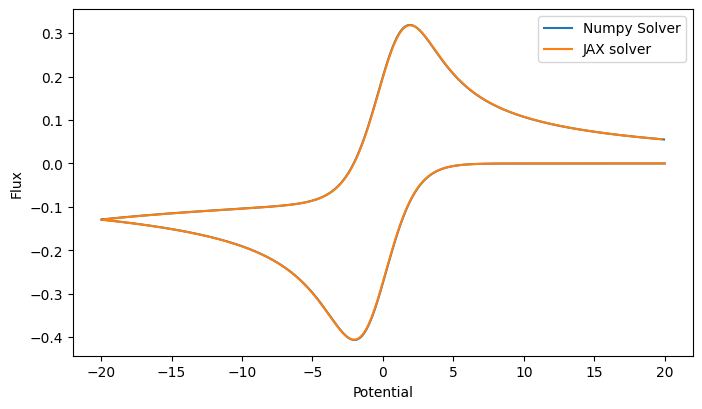

In [42]:
fig, ax = plt.subplots(figsize=(8,4.5))

ax.plot(E_numpy,flux_numpy,label='Numpy Solver')
ax.plot(E_JAX,flux_JAX,label="JAX solver")

ax.set_xlabel("Potential")
ax.set_ylabel("Flux")
ax.legend()

#Yeah! Both simulators agree with each other! 

## 4.Differentiable simulator and parameter estimation

In this tutorial, we fun the DiffEC for Fe Redox Voltammetry experiment with real experimental data.

## 4.1 Visualize the experimental data in dimensionless form 
In the DiffEC for Fe Redox Voltammetry folder, the ConvertToDimensionless.py converts the experimental data (DiffEC for Fe Redox Voltammmetry\5 mM Fe(3) 1 M H2SO4 on PtE.xlsx) into dimensionless form for future processing. The dimensionless data are stored in the "DiffEC for Fe Redox Voltammmetry\ExpData" folder.


<>:38: SyntaxWarning: invalid escape sequence '\s'
<>:38: SyntaxWarning: invalid escape sequence '\s'
C:\Users\nmero\AppData\Local\Temp\ipykernel_33784\1441481454.py:38: SyntaxWarning: invalid escape sequence '\s'
  ax.plot(df.iloc[:,0],df.iloc[:,1],lw=3,label=f'$\sigma$={sigma:.2E}, $\\nu=${scan_rate:.2f} V/s',color=colors[index])


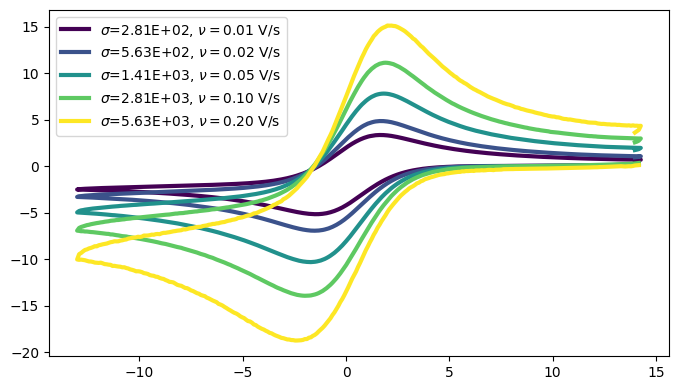

In [43]:
from matplotlib.cm import viridis
from matplotlib import pyplot as plt
import numpy as np 
import pandas as pd
exp_dimensionless_files = [
    r"DiffEC for Fe Redox Voltammmetry/ExpData/Exp Dimensionless sigma=2.8137E+02 theta_i=1.4269E+01 theta_v=-1.2992E+01 dA=4.63E-01.csv",
    r"DiffEC for Fe Redox Voltammmetry/ExpData/Exp Dimensionless sigma=5.6273E+02 theta_i=1.4269E+01 theta_v=-1.2992E+01 dA=4.63E-01.csv",
    r"DiffEC for Fe Redox Voltammmetry/ExpData/Exp Dimensionless sigma=1.4068E+03 theta_i=1.4269E+01 theta_v=-1.2992E+01 dA=4.63E-01.csv",
    r"DiffEC for Fe Redox Voltammmetry/ExpData/Exp Dimensionless sigma=2.8137E+03 theta_i=1.4269E+01 theta_v=-1.2992E+01 dA=4.63E-01.csv",
    r"DiffEC for Fe Redox Voltammmetry/ExpData/Exp Dimensionless sigma=5.6273E+03 theta_i=1.4269E+01 theta_v=-1.2992E+01 dA=4.63E-01.csv"
]
scan_rates = [0.01,0.02,0.05,0.1,0.2]
r_e = 0.85e-3 # Radius of electrode, m 
c_bulk = 4.85 # mol per cubic meter 
Dref = 1e-9 #m^2 s^-1
R = 8.314 # Gas constant J/(mol K)
T = 298 # K
F = 96485 # C/mol 

A = np.pi* r_e**2 # Area of electrode, m^2 

DA = 4.63e-10 #m^2 s^-1

Dref = 1e-9 #m^2 s^-1

ERef = 0.4336 # Formal Potential of Fe2+/Fe3+ couple



fig,ax = plt.subplots(figsize=(8,4.5))
colors = viridis(np.linspace(0,1,len(scan_rates)))
for index, (scan_rate, exp_dimensionless_file)  in enumerate(zip(scan_rates,exp_dimensionless_files)):
    sigma = (r_e**2/Dref)*(F/(R*T))*scan_rate  # sigma is the dimensionless scan rate 


    df = pd.read_csv(exp_dimensionless_file)

    ax.plot(df.iloc[:,0],df.iloc[:,1],lw=3,label=f'$\sigma$={sigma:.2E}, $\\nu=${scan_rate:.2f} V/s',color=colors[index])


ax.legend()



## 4.2 Obtain Initial Guess


In [44]:

epochs=400
logK0_initial  = 1.0 #The initial guess of dimensionless K0 in logscale
alpha_initial = 0.4  # The initial guess of cathodic transfer coefficient 
beta_initial = 0.4  #The initial guess of anodic transfer coefficient 
dA_initial = 0.4  #The initial guess of diffusion coefficient

logK0_initial_range = 0.5 
alpha_initial_range = 0.2
beta_initial_range = 0.2
dA_initial_range = 0.2 

lr=1e-3 #Learning rate 
optimizer_name = "sgd"

Theta_i = 14.268850309900179
Theta_v = -12.991507814909113


logK0_initial = np.random.uniform(logK0_initial-logK0_initial_range,logK0_initial+logK0_initial_range)
alpha_initial = np.random.uniform(alpha_initial-alpha_initial_range,alpha_initial+alpha_initial_range)
beta_initial = np.random.uniform(beta_initial-beta_initial_range,beta_initial+beta_initial_range)
dA_initial = np.random.uniform(dA_initial-dA_initial_range,dA_initial+dA_initial_range)





print(f"The initial guess of K0 in log scale is {logK0_initial:.2f}")
print(f"The initial guess of alpha is {alpha_initial:.2f}")
print(f"The initial guess of beta is {beta_initial:.2f}")
print(f"The initial guess of dA (average diffusion coefficient is) {dA_initial:.2f}")

The initial guess of K0 in log scale is 1.32
The initial guess of alpha is 0.22
The initial guess of beta is 0.37
The initial guess of dA (average diffusion coefficient is) 0.42


## 4.3 Differentiable loss function  and helper functions

We wrap the simulation function (diffEC_JAX_simulation) into the loss function, so that the loss function is also fully differentiable with respect to parameters. 

In [ ]:
from scipy import interpolate

def flux_sampling(time_array,df_FD,maxT):
    #Sample experimental data 
    interpolated_flux = np.zeros_like(time_array)
    time_array_length = len(time_array)
    df_FD_forward = df_FD.iloc[:int(len(df_FD)/2)]
    df_FD_reverse = df_FD.iloc[int(len(df_FD)/2):]
    forward_scan_time_array = time_array[:int(time_array_length/2)]
    reverse_scan_time_array  = time_array[int(time_array_length/2):]
    f_forward = interpolate.interp1d(np.linspace(0.0,maxT/2.0,num=len(df_FD_forward)),df_FD_forward.iloc[:,1],fill_value="extrapolate")
    f_reverse = interpolate.interp1d(np.linspace(maxT/2.0,maxT,num=len(df_FD_reverse)),df_FD_reverse.iloc[:,1],fill_value="extrapolate")
    interpolated_flux[:int(time_array_length/2)] = f_forward(forward_scan_time_array)
    interpolated_flux[int(time_array_length/2):] = f_reverse(reverse_scan_time_array)
    return interpolated_flux


def load_experimental_flux(sigma,file_name):
    
    df = pd.read_csv(file_name)

    nTimeSteps = jnp.round(2*jnp.fabs(Theta_v-Theta_i)/deltaTheta*cycles)
    deltaT = deltaTheta/sigma
    maxT = 2.0*jnp.abs(Theta_v-Theta_i)/sigma * cycles
    time_array = jnp.arange(0,maxT,deltaT)

    flux_sampled = flux_sampling(time_array=time_array,df_FD=df,maxT=maxT)

    flux_sampled = jnp.array(flux_sampled)

    return flux_sampled

def mse(y_true,y_pred):
    loss = jnp.mean((y_true - y_pred) ** 2)
    return loss


def compute_loss(params,sigmas,experimental_fluxes):
    #Construct the loss function 

    logK0_guess = params[0]
    K0_guess = jnp.power(10,logK0_guess)
    alpha_guess = params[1]
    beta_guess = params[2]
    dA_guess = params[3]

    losses = 0

    for i,sigma in enumerate(sigmas):
        #Iterating voltammograms at different dimensionless scan rates and adding up the losses value.
        theta_simulated, flux_simulated = diffEC_JAX_simulation(sigma=sigma,K0=K0_guess,alpha=alpha_guess,beta=beta_guess,theta_i=Theta_i,theta_v=Theta_v,dA=dA_guess,dB=dA_guess)
        #Caluate the loss 
        loss = mse(experimental_fluxes[i],flux_simulated)
        #Add up the losses
        losses += loss

    return losses

## 4.4 Perform 1 step of DiffEC optimization

Since the entire optimization process is pretty time-consuming and memory-intensive, here we perform only one-step of optimization in the following order. 
At the end of optimization, we will print the initial guess, loss, gradients of the loss, and the updated parameters. 

In [ ]:
import re

#Initialize optimizers
if optimizer_name == "sgd":
    optimizer = optax.sgd(lr,momentum=0.5)
elif optimizer_name =='adam':
    optimizer = optax.adam(lr)
else:
    raise ValueError



#Again, obtain the dimensionless scan rate from experimental file name
sigmas = []
def expParameters(file_name):
    file_name = file_name.replace('.csv','')
    pattern = re.compile(r'sigma=([\d.]+[eE][+-][\d]+)')
    sigma = float(pattern.findall(file_name)[0])

    pattern = re.compile(r'theta_i=([\d.]+[eE][+-][\d]+)')
    theta_i = float(pattern.findall(file_name)[0])

    pattern = re.compile(r'theta_v=([+-][\d.]+[eE][+-][\d]+)')
    theta_v = float(pattern.findall(file_name)[0])

    pattern = re.compile(r'dA=([\d.]+[eE][+-][\d]+)')
    dA = float(pattern.findall(file_name)[0])

    return sigma, theta_i,theta_v,dA


for exp_dimensionless_file in exp_dimensionless_files:
    sigma,theta_i,theta_v,dA = expParameters(exp_dimensionless_file)
    sigmas.append(sigma)



experimental_fluxes = []
for sigma,experimental_file in zip(sigmas,exp_dimensionless_files):
    flux_sampled = load_experimental_flux(sigma,experimental_file)
    experimental_fluxes.append(flux_sampled)

experimental_fluxes = jnp.array(experimental_fluxes)




logK0_guess = logK0_initial
alpha_guess = alpha_initial
beta_guess = beta_initial
dA_guess = dA_initial
params = jnp.array([logK0_guess,alpha_guess,beta_guess,dA_guess])
jax.debug.print("Parameters before optimization {params}",params=params)


#An important step, converting the compute_loss function into a differentiable function
value_and_grad = jax.value_and_grad(compute_loss,argnums=0)



loss,grads = value_and_grad(params,sigmas,experimental_fluxes)

opt_state = optimizer.init(params)
updates,opt_state = optimizer.update(grads, opt_state,params)
params = optax.apply_updates(params,updates)



jax.debug.print("The four optimized parameters are: logK0, alpha, beta, and dA")
jax.debug.print("Loss values {loss}",loss=loss)
jax.debug.print("Loss gradients {grads}",grads=grads)
jax.debug.print("Parameters after optimization {params}",params=params)




Parameters before optimization [1.32423326 0.22072352 0.37437342 0.41820474]


100%|██████████| 273/273 [00:19<00:00, 14.04it/s]


Loss values 12.70322068089608
Loss gradients [Array(-3.24740235e-15, dtype=float64), Array(3.6429193e-15, dtype=float64)]
Parameters after optimization [1.34885879 0.27778986 0.41087362 0.46601499]
